In [1]:
!nvidia-smi

Fri Aug 28 09:51:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
!pip install -q ultralytics==8.4.130

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.4 MB/s eta 0:00:00


In [4]:
import ultralytics
import torch

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.130
PyTorch: 2.11.0+cu128
GPU: Tesla T4


In [6]:
!pip install -q gdown

In [7]:
!gdown --fuzzy "https://drive.google.com/file/d/1MAUSH06nXjBy1kPP2kdqLTBjT5I5qUjS/view?usp=drive_link" \
    -O /content/groceries-yolo.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1MAUSH06nXjBy1kPP2kdqLTBjT5I5qUjS
From (redirected): https://drive.google.com/uc?id=1MAUSH06nXjBy1kPP2kdqLTBjT5I5qUjS&confirm=t&uuid=8a123440-e1f8-4ce3-a227-e11a8f10557f
To: /content/groceries-yolo.tar.gz
100% 371M/371M [00:03<00:00, 101MB/s] 


In [8]:
!ls -lh /content/groceries-yolo.tar.gz

-rw-r--r-- 1 root root 354M Aug 28 09:50 /content/groceries-yolo.tar.gz


In [9]:
!mkdir -p /content/retail-data
!tar -xzf /content/groceries-yolo.tar.gz -C /content/retail-data

In [10]:
from pathlib import Path

YOLO_ROOT = Path("/content/retail-data/yolo")

for split in ["train", "val", "test"]:
    n_images = len(list((YOLO_ROOT / "images" / split).glob("*")))
    n_labels = len(list((YOLO_ROOT / "labels" / split).glob("*.txt")))
    print(split, n_images, n_labels)

train 3957 3957
val 495 495
test 495 495


In [11]:
import yaml

class_names = [
    "beans",
    "cake",
    "candy",
    "cereal",
    "chips",
    "chocolate",
    "coffee",
    "corn",
    "fish",
    "flour",
    "honey",
    "jam",
    "juice",
    "milk",
    "nuts",
    "oil",
    "pasta",
    "rice",
    "soda",
    "spices",
    "sugar",
    "tea",
    "tomato_sauce",
    "vinegar",
    "water",
]

dataset_config = {
    "path": "/content/retail-data/yolo",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(class_names)},
}

with open("/content/groceries.yaml", "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False)

print(open("/content/groceries.yaml").read())

path: /content/retail-data/yolo
train: images/train
val: images/val
test: images/test
names:
  0: beans
  1: cake
  2: candy
  3: cereal
  4: chips
  5: chocolate
  6: coffee
  7: corn
  8: fish
  9: flour
  10: honey
  11: jam
  12: juice
  13: milk
  14: nuts
  15: oil
  16: pasta
  17: rice
  18: soda
  19: spices
  20: sugar
  21: tea
  22: tomato_sauce
  23: vinegar
  24: water



In [12]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [13]:
smoke_results = model.train(
    data="/content/groceries.yaml",
    epochs=1,
    imgsz=320,
    batch=32,
    device=0,
    workers=2,
    project="/content/runs",
    name="smoke_test",
    seed=42,
)

New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/groceries.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

In [14]:
from ultralytics import YOLO

baseline_model = YOLO("yolo11n.pt")

baseline_results = baseline_model.train(
    data="/content/groceries.yaml",
    epochs=50,
    imgsz=224,
    batch=32,
    device=0,
    workers=2,
    seed=42,
    patience=10,
    project="/content/runs",
    name="baseline_yolo11n_224",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/groceries.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

In [1]:
!zip -qr /content/baseline_yolo11n_224.zip \
    /content/runs/baseline_yolo11n_224


zip error: Nothing to do! (try: zip -qr /content/baseline_yolo11n_224.zip . -i /content/runs/baseline_yolo11n_224)


In [4]:
!ls -lah /content/runs

ls: cannot access '/content/runs': No such file or directory


In [6]:
!find /content -type f \( -name "best.pt" -o -name "results.png" \) 2>/dev/null

In [2]:
!mkdir -p /content/retail-data
!tar -xzf /content/groceries-yolo.tar.gz -C /content/retail-data


tar (child): /content/groceries-yolo.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


In [4]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1MAUSH06nXjBy1kPP2kdqLTBjT5I5qUjS/view?usp=drive_link" \
    -O /content/groceries-yolo.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1MAUSH06nXjBy1kPP2kdqLTBjT5I5qUjS
From (redirected): https://drive.google.com/uc?id=1MAUSH06nXjBy1kPP2kdqLTBjT5I5qUjS&confirm=t&uuid=610f3c76-79fe-499b-bcc7-4656f8934501
To: /content/groceries-yolo.tar.gz
100% 371M/371M [00:03<00:00, 112MB/s]


In [5]:
!ls -lh /content/groceries-yolo.tar.gz

-rw-r--r-- 1 root root 354M Aug 28 09:50 /content/groceries-yolo.tar.gz


In [6]:
!mkdir -p /content/retail-data
!tar -xzf /content/groceries-yolo.tar.gz -C /content/retail-data

In [7]:
from pathlib import Path

YOLO_ROOT = Path("/content/retail-data/yolo")

for split in ["train", "val", "test"]:
    print(
        split,
        len(list((YOLO_ROOT / "images" / split).glob("*"))),
        len(list((YOLO_ROOT / "labels" / split).glob("*.txt")))
    )

train 3957 3957
val 495 495
test 495 495


In [8]:
!pip install -q ultralytics==8.4.130

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 6.6 MB/s eta 0:00:00


In [9]:
import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.130
CUDA: True
GPU: Tesla T4


In [10]:
import yaml

class_names = [
    "beans", "cake", "candy", "cereal", "chips",
    "chocolate", "coffee", "corn", "fish", "flour",
    "honey", "jam", "juice", "milk", "nuts",
    "oil", "pasta", "rice", "soda", "spices",
    "sugar", "tea", "tomato_sauce", "vinegar", "water",
]

dataset_config = {
    "path": "/content/retail-data/yolo",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(class_names)},
}

with open("/content/groceries.yaml", "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False)

In [11]:
print(open("/content/groceries.yaml").read())

path: /content/retail-data/yolo
train: images/train
val: images/val
test: images/test
names:
  0: beans
  1: cake
  2: candy
  3: cereal
  4: chips
  5: chocolate
  6: coffee
  7: corn
  8: fish
  9: flour
  10: honey
  11: jam
  12: juice
  13: milk
  14: nuts
  15: oil
  16: pasta
  17: rice
  18: soda
  19: spices
  20: sugar
  21: tea
  22: tomato_sauce
  23: vinegar
  24: water



In [12]:
from ultralytics import YOLO

baseline_model = YOLO("yolo11n.pt")

baseline_results = baseline_model.train(
    data="/content/groceries.yaml",
    epochs=50,
    imgsz=224,
    batch=32,
    device=0,
    workers=2,
    seed=42,
    patience=10,
    project="/content/runs",
    name="baseline_yolo11n_224",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/groceries.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

In [13]:
from pathlib import Path

RUN_DIR = Path("/content/runs/baseline_yolo11n_224")

print("Run directory:", RUN_DIR.exists())
print("best.pt:", (RUN_DIR / "weights" / "best.pt").exists())
print("last.pt:", (RUN_DIR / "weights" / "last.pt").exists())
print("results.png:", (RUN_DIR / "results.png").exists())

Run directory: True
best.pt: True
last.pt: True
results.png: True


In [14]:
import shutil

archive = shutil.make_archive(
    "/content/baseline_yolo11n_224",
    "zip",
    RUN_DIR
)

print(archive)

/content/baseline_yolo11n_224.zip


In [15]:
!ls -lh /content/baseline_yolo11n_224.zip

-rw-r--r-- 1 root root 14M Aug 28 13:45 /content/baseline_yolo11n_224.zip


In [17]:
from google.colab import files

files.download("/content/baseline_yolo11n_224.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

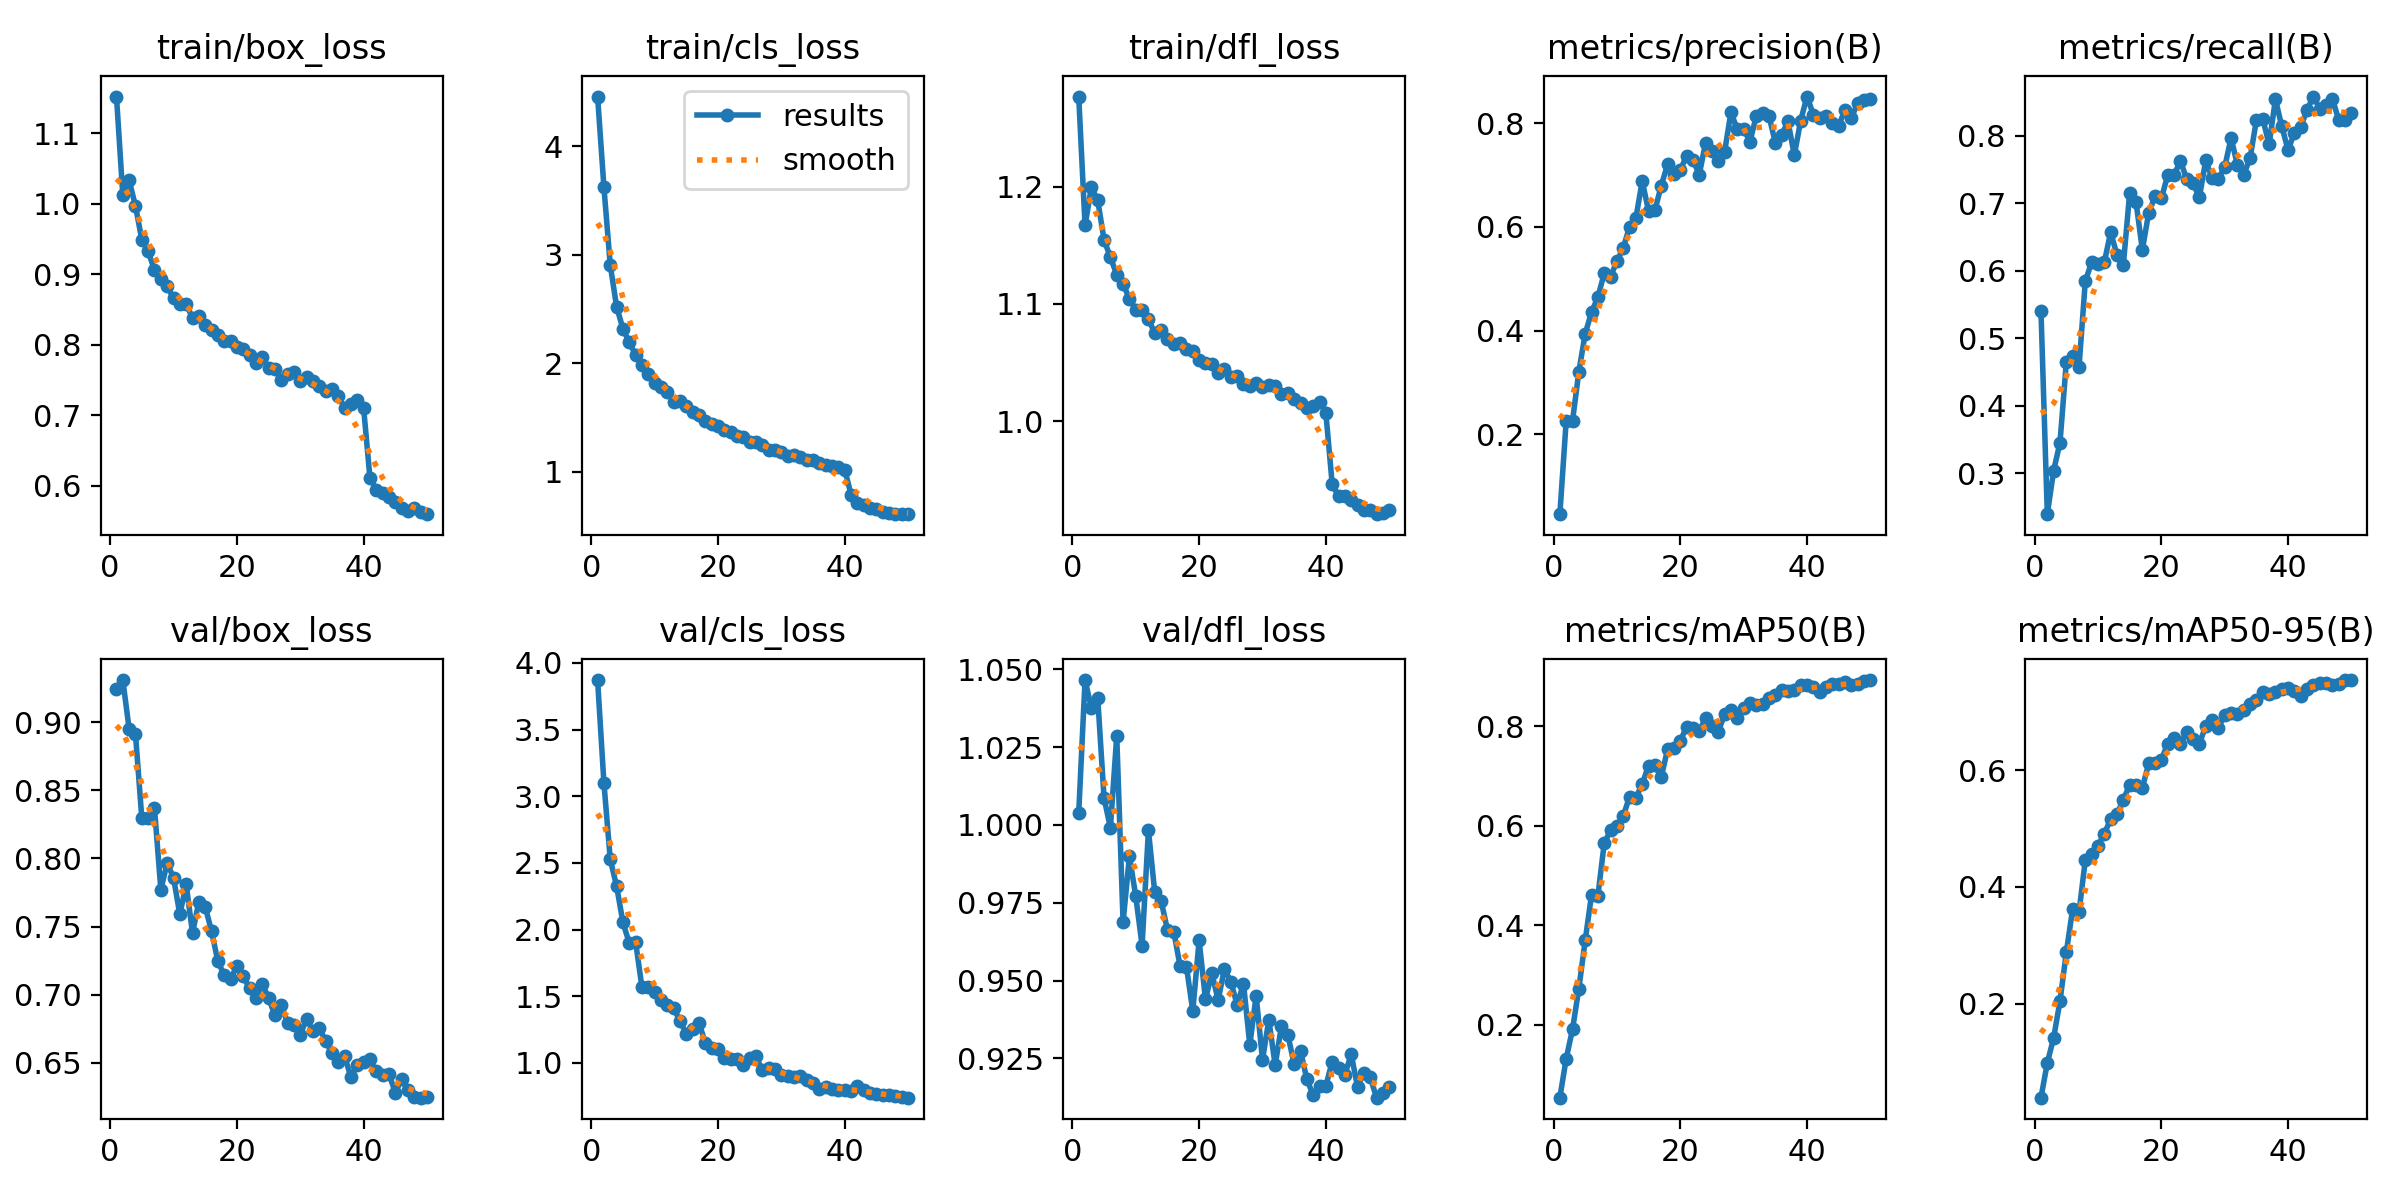

In [18]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/runs/baseline_yolo11n_224/results.png"
    )
)

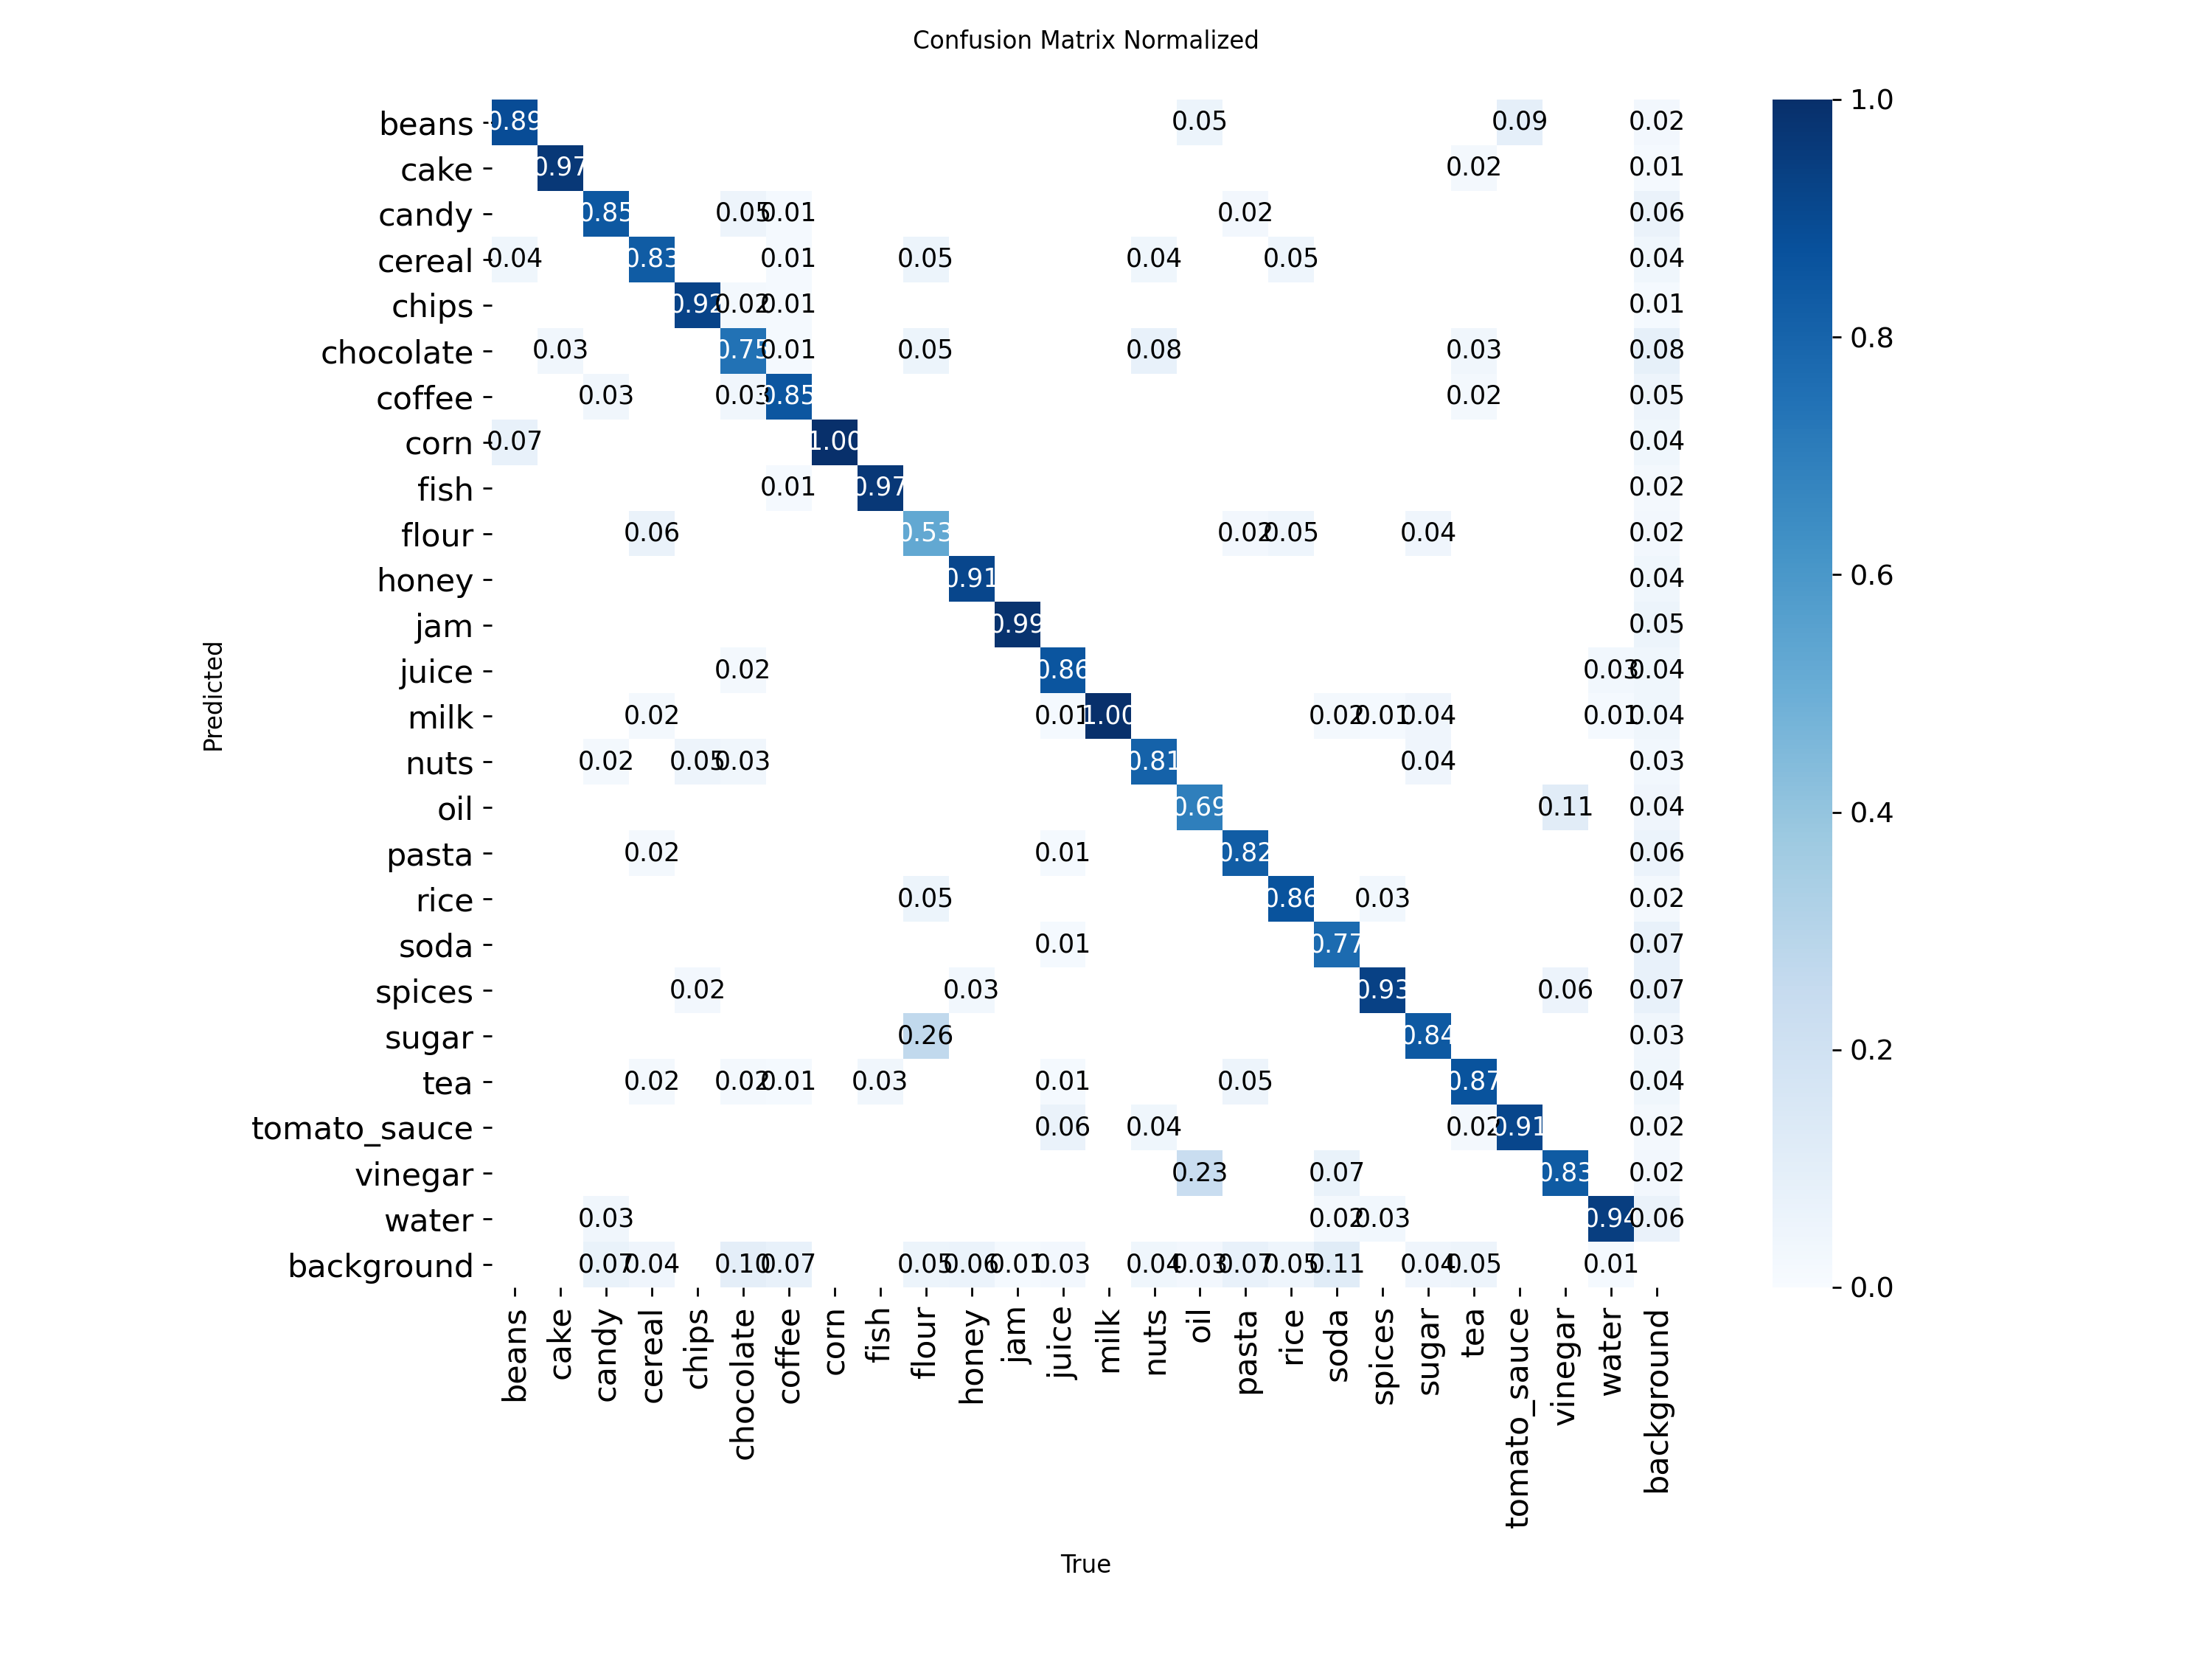

In [19]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/runs/baseline_yolo11n_224/confusion_matrix_normalized.png"
    )
)

In [20]:
from ultralytics import YOLO

model_s = YOLO("yolo11s.pt")

results_s = model_s.train(
    data="/content/groceries.yaml",
    epochs=50,
    imgsz=224,
    batch=32,
    device=0,
    workers=2,
    seed=42,
    patience=10,
    project="/content/runs",
    name="experiment1_yolo11s_224",
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/groceries.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

In [21]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/experiment1_yolo11s_224",
    "zip",
    "/content/runs/experiment1_yolo11s_224"
)

files.download("/content/experiment1_yolo11s_224.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from ultralytics import YOLO

final_model = YOLO(
    "/content/runs/experiment1_yolo11s_224/weights/best.pt"
)

In [25]:
test_results = final_model.val(
    data="/content/groceries.yaml",
    split="test",
    imgsz=224,
    batch=32,
    device=0,
    plots=True,
    project="/content/runs",
    name="final_test_yolo11s_224"
)

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,422,475 parameters, 0 gradients, 21.5 GFLOPs
WARNING ⚠️ test: Slow image access detected (ping: 0.0±0.0 ms, read: 11.6±4.2 MB/s, size: 73.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
test: Scanning /content/retail-data/yolo/labels/test... 495 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 495/495 413.3it/s 1.2s
test: New cache created: /content/retail-data/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.3it/s 3.7s
                   all        495       1173      0.897      0.849      0.917      0.797
                 beans         13         24      0.789          1      0.884      0.813
                  cake         16         22       0.79      0.909      0.912      0.80

In [26]:
from ultralytics import YOLO

final_model = YOLO(
    "/content/runs/experiment1_yolo11s_224/weights/best.pt"
)

In [27]:
onnx_path = final_model.export(
    format="onnx",
    imgsz=224,
    simplify=True,
    opset=17
)

print(onnx_path)

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11s summary (fused): 101 layers, 9,422,475 parameters, 0 gradients, 2.6 GFLOPs

PyTorch: starting from '/content/runs/experiment1_yolo11s_224/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 29, 1029) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 355ms
Prepared 4 packages in 1.94s
Installed 4 packages in 277ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 17...
ONNX

In [28]:
from pathlib import Path

onnx_path = Path(onnx_path)

print("Exists:", onnx_path.exists())
print("Size MB:", onnx_path.stat().st_size / (1024 * 1024))

Exists: True
Size MB: 36.06580352783203


In [29]:
from google.colab import files
files.download(str(onnx_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
!pip install -q onnxruntime

In [31]:
onnx_model = YOLO(str(onnx_path))

In [32]:
from pathlib import Path

sample_image = next(
    Path("/content/retail-data/yolo/images/val").glob("*")
)

print(sample_image)

/content/retail-data/yolo/images/val/CORN0062.png


In [33]:
pt_result = final_model.predict(
    source=str(sample_image),
    imgsz=224,
    conf=0.25,
    verbose=False
)[0]

In [34]:
onnx_result = onnx_model.predict(
    source=str(sample_image),
    imgsz=224,
    conf=0.25,
    verbose=False
)[0]

Loading /content/runs/experiment1_yolo11s_224/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 5 packages in 271ms
Prepared 1 package in 6.22s
Installed 1 package in 66ms
 + onnxruntime-gpu==1.29.0

requirements: AutoUpdate success ✅ 6.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.29.0 with CPUExecutionProvider


In [35]:
sample_image = next(
    Path("/content/retail-data/yolo/images/val").glob("*")
)

pt_result = final_model.predict(
    source=str(sample_image),
    imgsz=224,
    conf=0.25,
    device="cpu",
    verbose=False
)[0]

onnx_result = onnx_model.predict(
    source=str(sample_image),
    imgsz=224,
    conf=0.25,
    verbose=False
)[0]

print("PyTorch detections:", len(pt_result.boxes))
print("ONNX detections:", len(onnx_result.boxes))

PyTorch detections: 10
ONNX detections: 10


In [36]:
print("PyTorch")
for box in pt_result.boxes:
    print(
        "class:", int(box.cls.item()),
        "conf:", round(float(box.conf.item()), 4),
        "box:", box.xyxy.cpu().numpy().round(2)
    )

print("\nONNX")
for box in onnx_result.boxes:
    print(
        "class:", int(box.cls.item()),
        "conf:", round(float(box.conf.item()), 4),
        "box:", box.xyxy.cpu().numpy().round(2)
    )

PyTorch
class: 7 conf: 0.957 box: [[     149.99       65.72       202.4      141.33]]
class: 7 conf: 0.9559 box: [[      38.19       63.46       97.41      151.41]]
class: 7 conf: 0.9484 box: [[      34.75       154.6       92.48      212.89]]
class: 7 conf: 0.9385 box: [[     103.65       62.72      151.91      139.48]]
class: 7 conf: 0.9351 box: [[          0       59.22       38.59      149.44]]
class: 7 conf: 0.9284 box: [[          0      152.41       36.14         213]]
class: 7 conf: 0.8801 box: [[     197.41       68.38         224      144.47]]
class: 7 conf: 0.8791 box: [[      97.14      160.53      152.86      194.76]]
class: 7 conf: 0.8543 box: [[     153.52       163.2      208.91      197.22]]
class: 7 conf: 0.4237 box: [[     208.76      166.26      223.96      196.93]]

ONNX
class: 7 conf: 0.957 box: [[     149.99       65.72       202.4      141.33]]
class: 7 conf: 0.9559 box: [[      38.19       63.46       97.41      151.41]]
class: 7 conf: 0.9484 box: [[      34.75

In [37]:
from google.colab import files

files.download(
    "/content/runs/experiment1_yolo11s_224/weights/best.pt"
)

files.download(
    "/content/runs/experiment1_yolo11s_224/weights/best.onnx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>